<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
## Write your code here
instructions = ["columns", "dtypes", "describe()", "shape"]

for instruction in instructions:
    print(eval(f"df.{instruction}"))
    print("\n"+"="*50+"\n")

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='object', length=114)


ResponseId               int64
MainBranch              object
Age                     object
Employment              object
RemoteWork              object
                        ...   
JobSatPoints_11        float64
SurveyLength            object
SurveyEase              object
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object


         ResponseId      CompTotal       WorkExp  JobSatPoints_1  \
count  65437.000000   3.374000e+04  29658.000000    29324.000000   
mean   32719.000000  2.963841e+145     11.466957       18.581094   
std    18890.179119  5.444117e+147 

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [4]:
## Write your code here
cols = ["Edlevel", "JobSat", "YearsCodePro", "LanguageHaveWorkedWith", "LanguageWantToWorkWith"]

for col in cols:
    print(f"{col}: ")
    for inf in ["dtypes","value_counts()", "isna().sum()", "mode()[0]", "median()"]:
        try:
            result = eval(f"df['{col}'].{inf}")
            print(f"The {inf} of {col} is:\n{result}")
        except Exception as e:
            print(f"Error evaluating {inf} on {col}: {e}")
    print("\n" + "="*50 + "\n")

Edlevel: 
Error evaluating dtypes on Edlevel: 'Edlevel'
Error evaluating value_counts() on Edlevel: 'Edlevel'
Error evaluating isna().sum() on Edlevel: 'Edlevel'
Error evaluating mode()[0] on Edlevel: 'Edlevel'
Error evaluating median() on Edlevel: 'Edlevel'


JobSat: 
The dtypes of JobSat is:
float64
The value_counts() of JobSat is:
JobSat
8.0     7509
7.0     6379
6.0     3751
9.0     3626
10.0    2251
5.0     1956
3.0     1165
4.0     1130
2.0      772
0.0      311
1.0      276
Name: count, dtype: int64
The isna().sum() of JobSat is:
36311
The mode()[0] of JobSat is:
8.0
The median() of JobSat is:
7.0


YearsCodePro: 
The dtypes of YearsCodePro is:
object
The value_counts() of YearsCodePro is:
YearsCodePro
2                     4168
3                     4093
5                     3526
10                    3251
4                     3215
Less than 1 year      2856
6                     2843
1                     2639
8                     2549
7                     2517
12         

In [8]:
df["EdLevel"].isna().sum()

np.int64(4653)

In [9]:
df["EdLevel"].value_counts()

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          24942
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       15557
Some college/university study without earning a degree                                 7651
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     5793
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2970
Associate degree (A.A., A.S., etc.)                                                    1793
Primary/elementary school                                                              1146
Something else                                                                          932
Name: count, dtype: int64

In [11]:
Ed_mode = df["EdLevel"].mode()[0]
Ed_mode 

'Bachelor’s degree (B.A., B.S., B.Eng., etc.)'

In [12]:
df["EdLevel"] = df["EdLevel"].fillna(Ed_mode)
df["EdLevel"]

0                                Primary/elementary school
1             Bachelor’s degree (B.A., B.S., B.Eng., etc.)
2          Master’s degree (M.A., M.S., M.Eng., MBA, etc.)
3        Some college/university study without earning ...
4        Secondary school (e.g. American high school, G...
                               ...                        
65432         Bachelor’s degree (B.A., B.S., B.Eng., etc.)
65433         Bachelor’s degree (B.A., B.S., B.Eng., etc.)
65434         Bachelor’s degree (B.A., B.S., B.Eng., etc.)
65435    Secondary school (e.g. American high school, G...
65436         Bachelor’s degree (B.A., B.S., B.Eng., etc.)
Name: EdLevel, Length: 65437, dtype: object

In [13]:
df['JobSat'].fillna(df['JobSat'].median(), inplace=True) 
df['JobSat']

df['LanguageHaveWorkedWith'].fillna(df['LanguageHaveWorkedWith'].mode()[0], inplace=True)
df['LanguageWantToWorkWith'].fillna(df['LanguageWantToWorkWith'].mode()[0], inplace=True)

df[['LanguageHaveWorkedWith','LanguageWantToWorkWith']]



/tmp/ipykernel_1889/457106148.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['JobSat'].fillna(df['JobSat'].median(), inplace=True)


0        7.0
1        7.0
2        7.0
3        7.0
4        7.0
        ... 
65432    7.0
65433    7.0
65434    7.0
65435    7.0
65436    7.0
Name: JobSat, Length: 65437, dtype: float64

In [14]:
df['LanguageHaveWorkedWith'].fillna(df['LanguageHaveWorkedWith'].mode()[0], inplace=True)
df['LanguageWantToWorkWith'].fillna(df['LanguageWantToWorkWith'].mode()[0], inplace=True)
df[['LanguageHaveWorkedWith','LanguageWantToWorkWith']]

/tmp/ipykernel_1889/191501673.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LanguageHaveWorkedWith'].fillna(df['LanguageHaveWorkedWith'].mode()[0], inplace=True)
/tmp/ipykernel_1889/191501673.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[

,LanguageHaveWorkedWith,LanguageWantToWorkWith
0,HTML/CSS;JavaScript;TypeScript,Python
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...
2,C#,C#
3,C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...,HTML/CSS;Java;JavaScript;PowerShell;Python;SQL...
4,C++;HTML/CSS;JavaScript;Lua;Python;Rust,C++;HTML/CSS;JavaScript;Lua;Python
...,...,...
65432,HTML/CSS;JavaScript;TypeScript,Python
65433,HTML/CSS;JavaScript;TypeScript,Python
65434,HTML/CSS;JavaScript;TypeScript,Python
65435,C;C++;Go;Lua;Objective-C;Python;Rust;SQL,Rust;SQL


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [15]:
## Write your code here
cols = ["Employment", "JobSat", "YearsCodePro"]

for col in cols:
    print(f"value count of {col}: ")
    print(df[col].value_counts())
    print("\n"+"="*50+"\n")

value count of Employment: 
Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looking

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


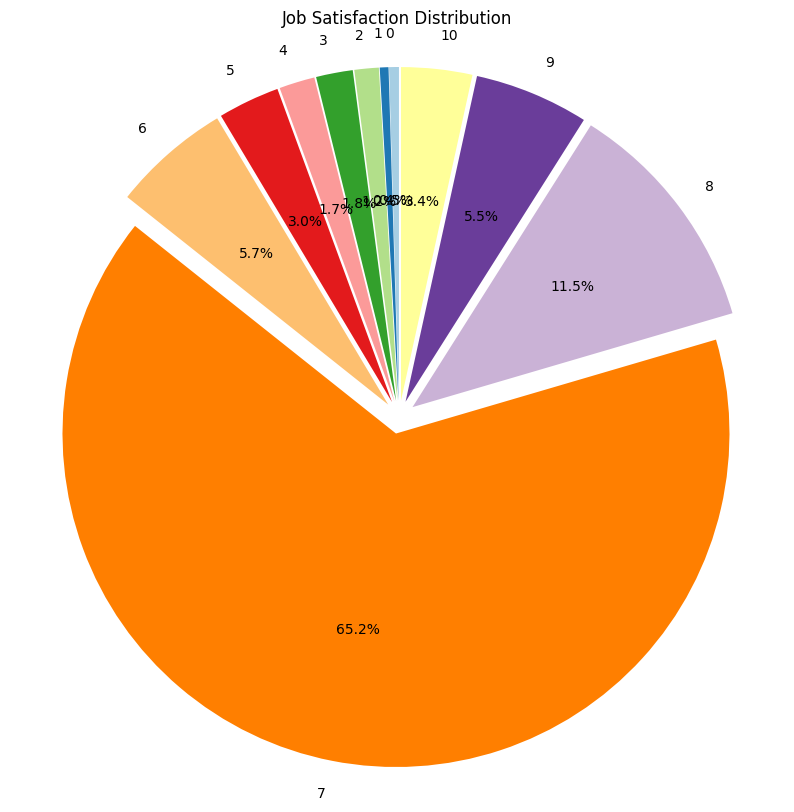

In [16]:
## Write your code here
job_sat_counts = df['JobSat'].value_counts().sort_index()  
labels = job_sat_counts.index.astype(int)
sizes = job_sat_counts.values
colors = plt.cm.Paired.colors 
explode = [0.05] * len(sizes)  

plt.figure(figsize=(10, 10))
plt.pie(x =sizes, explode=explode, labels = labels, colors =colors[:len(sizes)], autopct = '%1.1f%%',startangle= 90)
plt.title("Job Satisfaction Distribution")
plt.axis('equal')

plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


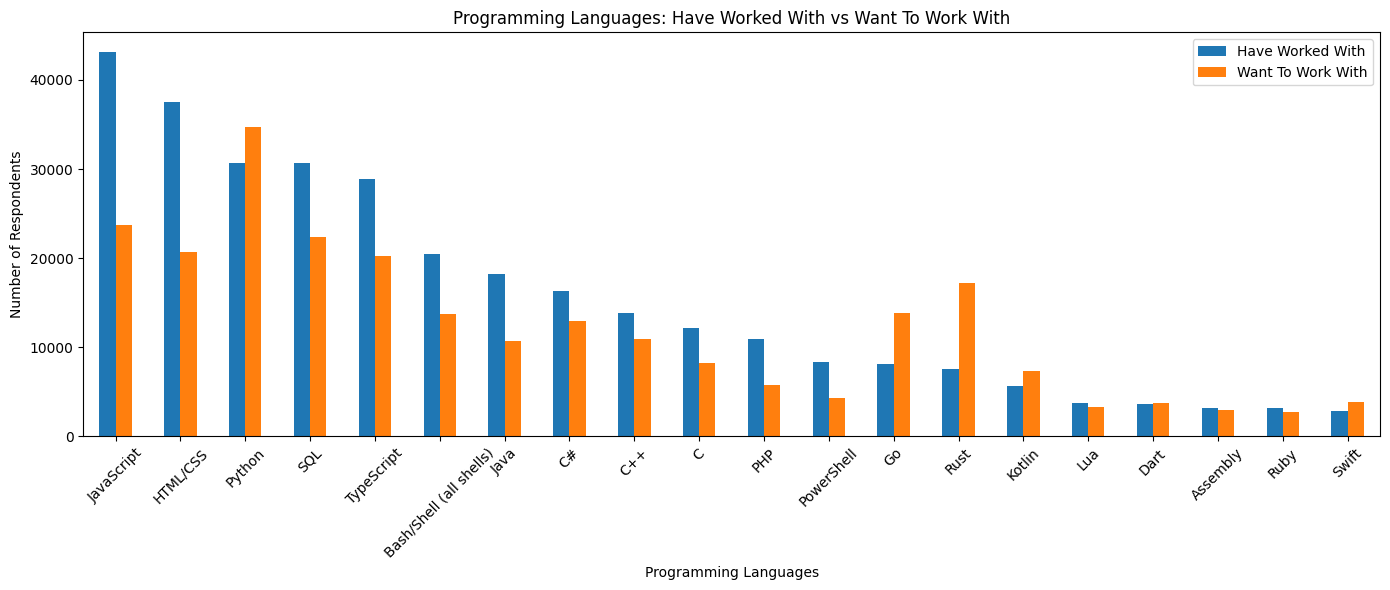

In [17]:
## Write your code here
from collections import Counter


worked_langs = df['LanguageHaveWorkedWith'].str.split(';').explode().str.strip()
want_langs = df['LanguageWantToWorkWith'].str.split(';').explode().str.strip()


worked_counts = Counter(worked_langs)
want_counts = Counter(want_langs)


all_languages = sorted(set(worked_counts) | set(want_counts))

data = {
    'Have Worked With': [worked_counts.get(lang, 0) for lang in all_languages],
    'Want To Work With': [want_counts.get(lang, 0) for lang in all_languages],
}

lang_df = pd.DataFrame(data, index=all_languages).sort_values(by='Have Worked With', ascending=False)


lang_df_top = lang_df.head(20)

lang_df_top.plot(kind='bar', figsize=(14, 6))
plt.title("Programming Languages: Have Worked With vs Want To Work With")
plt.xlabel("Programming Languages")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


In [18]:
## Write your code here
cols = ["RemoteWork", "Country"]
infs = ["dtypes", "isna().sum()", "value_counts()", "mode()[0]", "median()"]

for col in cols: 
    print(f"vital info on {col}: \n") 
    for inf in infs:
        try:
            result = eval(f"df['{col}']."+inf)
            print(f"{inf}: {result}")
        except Exception as e:
            print(f"Error finding {inf} of {col}: {e}")
    print("\n"+"="*50+"\n") 
    
print("end")

vital info on RemoteWork: 

dtypes: object
isna().sum(): 10631
value_counts(): RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64
mode()[0]: Hybrid (some remote, some in-person)
Error finding median() of RemoteWork: Cannot convert ['Remote' 'Remote' 'Remote' ... 'In-person'
 'Hybrid (some remote, some in-person)' nan] to numeric


vital info on Country: 

dtypes: object
isna().sum(): 6507
value_counts(): Country
United States of America                                11095
Germany                                                  4947
India                                                    4231
United Kingdom of Great Britain and Northern Ireland     3224
Ukraine                                                  2672
                                                        ...  
Micronesia, Federated States of...                          1
Nauru                     

In [19]:
df["RemWrk_cleaned"] = df["RemoteWork"].fillna(df["RemoteWork"].mode()[0])
df["Country_cleaned"] = df["Country"].fillna(df["RemoteWork"].mode()[0])

In [20]:
df['Country_cleaned'].unique() 

array(['United States of America',
       'United Kingdom of Great Britain and Northern Ireland', 'Canada',
       'Norway', 'Uzbekistan', 'Serbia', 'Poland', 'Philippines',
       'Bulgaria', 'Switzerland', 'India', 'Germany', 'Ireland', 'Italy',
       'Ukraine', 'Australia', 'Brazil', 'Japan', 'Austria',
       'Iran, Islamic Republic of...', 'France', 'Saudi Arabia',
       'Romania', 'Turkey', 'Nepal', 'Algeria', 'Sweden', 'Netherlands',
       'Croatia', 'Pakistan', 'Czech Republic',
       'Republic of North Macedonia', 'Finland', 'Slovakia',
       'Russian Federation', 'Greece', 'Israel', 'Belgium', 'Mexico',
       'United Republic of Tanzania', 'Hungary', 'Argentina', 'Portugal',
       'Sri Lanka', 'Latvia', 'China', 'Singapore', 'Lebanon', 'Spain',
       'South Africa', 'Lithuania', 'Viet Nam', 'Dominican Republic',
       'Indonesia', 'Kosovo', 'Morocco', 'Taiwan', 'Georgia',
       'San Marino', 'Tunisia', 'Bangladesh', 'Nigeria', 'Liechtenstein',
       'Denmark', 'Ecu

In [21]:
def region(country):
    if country in [ "United States of America", "Canada", "Mexico", "Bahamas", "Costa Rica",
        "Dominican Republic", "El Salvador", "Guatemala", "Honduras", "Jamaica",
        "Nicaragua", "Panama", "Trinidad and Tobago", "Barbados", "Belize",
        "Antigua and Barbuda", "Saint Kitts and Nevis"]:
        return "North America"
    elif country in ["Argentina", "Brazil", "Chile", "Bolivia", "Ecuador", "Peru",
        "Paraguay", "Uruguay", "Venezuela, Bolivarian Republic of...", "Guyana", "Suriname"]:
        return "South America"
    elif country in ["United Kingdom of Great Britain and Northern Ireland", "Norway", "Serbia", "Poland",
        "Bulgaria", "Switzerland", "Germany", "Ireland", "Italy", "Ukraine", "Austria",
        "France", "Romania", "Turkey", "Sweden", "Netherlands", "Croatia",
        "Czech Republic", "Republic of North Macedonia", "Finland", "Slovakia",
        "Russian Federation", "Greece", "Israel", "Belgium", "Hungary", "Portugal",
        "Latvia", "Spain", "Lithuania", "Kosovo", "Georgia", "San Marino",
        "Liechtenstein", "Denmark", "Albania", "Azerbaijan", "Luxembourg", "Montenegro",
        "Cyprus", "Slovenia", "Bosnia and Herzegovina", "Estonia", "Malta", "Belarus",
        "Republic of Moldova", "Isle of Man", "Armenia", "Iceland", "Andorra", "Monaco"]:
        return "Europe"
    elif country in ["Uzbekistan", "Philippines", "India", "Japan", "Iran, Islamic Republic of...",
        "Saudi Arabia", "Nepal", "Pakistan", "China", "Singapore", "Lebanon",
        "Taiwan", "Bangladesh", "Thailand", "Myanmar", "Republic of Korea",
        "Afghanistan", "Palestine", "United Arab Emirates", "Maldives", "Turkmenistan",
        "Hong Kong (S.A.R.)", "Lao People's Democratic Republic", "Mongolia", "Cambodia",
        "Syrian Arab Republic", "Iraq", "Kuwait", "Tajikistan", "North Korea",
        "Democratic People's Republic of Korea", "Qatar", "Bahrain", "Yemen",
        "Brunei Darussalam", "Bhutan", "Kyrgyzstan", "Oman"]:
        return "Asia"
    elif country in ["Algeria", "United Republic of Tanzania", "South Africa", "Morocco", "Tunisia",
        "Nigeria", "Egypt", "Ghana", "Rwanda", "Benin", "Zimbabwe", "Ethiopia",
        "Uganda", "Mauritius", "Kenya", "Gabon", "Madagascar", "Angola",
        "Democratic Republic of the Congo", "Namibia", "Senegal", "Zambia", "Swaziland",
        "Côte d'Ivoire", "Burundi", "Mauritania", "Sierra Leone", "Somalia",
        "Sudan", "Cameroon", "Malawi", "Burkina Faso", "Congo, Republic of the...",
        "Botswana", "Guinea-Bissau", "Mozambique", "Central African Republic",
        "Equatorial Guinea", "Libyan Arab Jamahiriya", "Guinea", "Niger", "Mali",
        "Liberia", "Chad", "Djibouti"]:
        return "Africa"
    else:
        return "Nomadic"

df['Region'] = df['Country_cleaned'].apply(region)



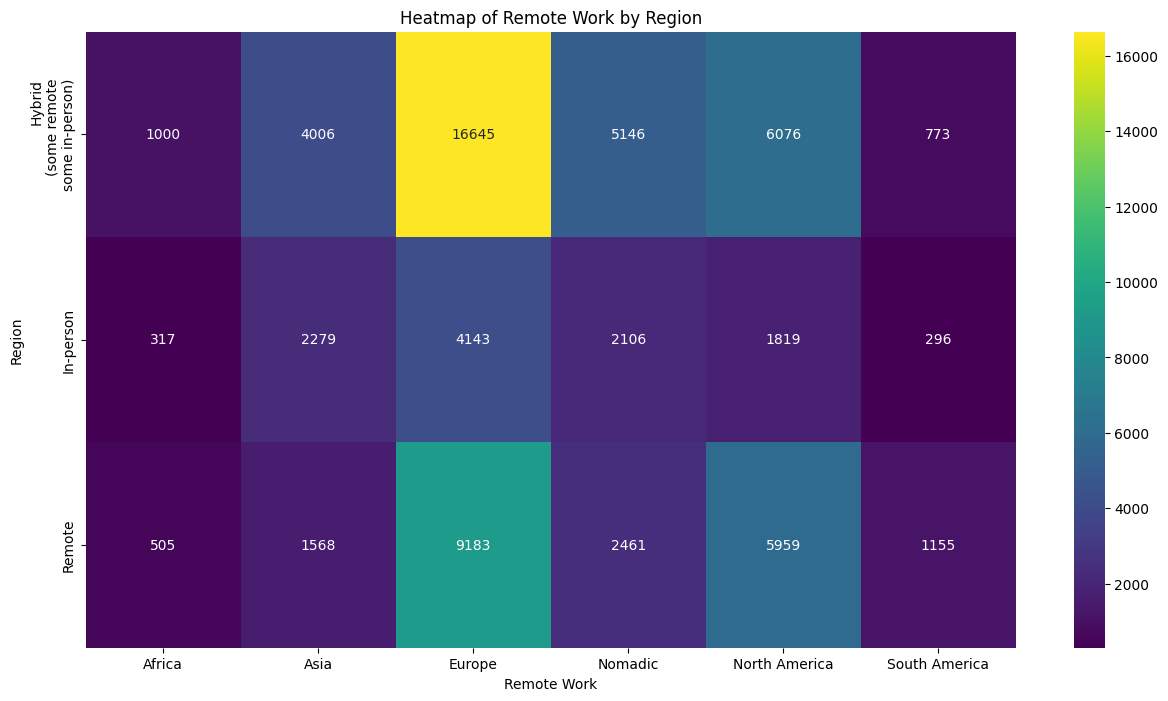

In [22]:
df['RemWrk_cleaned'] = df['RemWrk_cleaned'].replace({"Hybrid (some remote, some in-person)": "Hybrid\n(some remote\nsome in-person)",
    "In-person": "In-person",
    "Remote": "Remote"})

remwrk_by_region = pd.crosstab(df["RemWrk_cleaned"],df['Region'])

plt.figure(figsize = (15, 8))
sns.heatmap(remwrk_by_region, cmap="viridis", annot=True, fmt= 'g', xticklabels=True, yticklabels=True)

plt.title("Heatmap of Remote Work by Region")
plt.xlabel("Remote Work")
plt.ylabel('Region')

plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [23]:
## Write your code here
df["JobSat"].isna().sum()

np.int64(0)

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


In [27]:
## Write your code here
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,RemWrk_cleaned,Country_cleaned,Region
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,Remote,United States of America,North America
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,NaN,NaN,NaN,7.0,Remote,United Kingdom of Great Britain and Northern I...,Europe
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,Appropriate in length,Easy,NaN,7.0,Remote,United Kingdom of Great Britain and Northern I...,Europe
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,Too long,Easy,NaN,7.0,Hybrid\n(some remote\nsome in-person),Canada,North America
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,Too short,Easy,NaN,7.0,Hybrid\n(some remote\nsome in-person),Norway,Europe


### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [ ]:
## Write your code here

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
